# LC scenario WB and discharge analysis August 2026


In [1]:
# Install required packages
import pandas as pd
from pathlib import Path
import os                      
import numpy as np
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# Scenario colours 
scenario_colours = {
    "Baseline": "#81878b",
    "A2": "#db24ce",
    "C": "#16c216",
}

scenario_col = {
    "Baseline": "grey",
        "A2": "orchid",
        "C": "dodgerblue",
        "A1": "darkgreen",
        "M": "blue"
}

def get_scenario_color(key):
    return scenario_colours.get(key, "grey")

In [54]:
# Discharge data
D_baseline = pd.read_csv("../Data/LULC/Eddleston_LC_baselineDetailedTS_M11.txt", engine="python", sep="\\t")
D_baseline["Time"] = pd.to_datetime(D_baseline["Time"])
D_baseline = D_baseline.set_index("Time")

D_m = pd.read_csv("../Data/LULC/Eddleston_LC_MDetailedTS_M11.txt", engine="python", sep="\\t")
D_m["Time"] = pd.to_datetime(D_m["Time"])
D_m = D_m.set_index("Time")

D_a1 = pd.read_csv("../Data/LULC/Eddleston_LC_A1DetailedTS_M11.txt", engine="python", sep="\\t")
D_a1["Time"] = pd.to_datetime(D_a1["Time"])
D_a1 = D_a1.set_index("Time")

D_a2 = pd.read_csv("../Data/LULC/Eddleston_LC_A2DetailedTS_M11.txt", engine="python", sep="\\t")
D_a2["Time"] = pd.to_datetime(D_a2["Time"])
D_a2 = D_a2.set_index("Time")

D_c = pd.read_csv("../Data/LULC/Eddleston_LC_CDetailedTS_M11.txt", engine="python", sep="\\t")
D_c["Time"] = pd.to_datetime(D_c["Time"])
D_c = D_c.set_index("Time")

In [23]:
# Water balance data
# Load only overland flow to river (OL) and actual ET outputs (ET)

def subset_balance_columns(df):
    subset = df[["OL->River/MOUSE", "Evapotrans"]].copy()
    subset.index.name = "Time"
    subset.columns = ["OL", "ET"]
    return subset

def load_subcatchment_data(base_dir, scenarios):
    data = {}
    for key, filename in scenarios.items():
        path = base_dir / filename
        if not path.exists():
            continue
        df = pd.read_csv(path, sep="\t")
        df["Time"] = pd.to_datetime(df["Time"])
        df = df.set_index("Time")
        data[key] = subset_balance_columns(df)
    return data

root = Path.cwd().resolve()
if root.name == "Code":
    root = root.parent

base_dir = root / "Data" / "LULC" / "WB"

print(base_dir)
print(list(base_dir.glob("*.txt")))

# SB
SB_data = load_subcatchment_data(
    Path("../Data/LULC/WB"),
    {
        "baseline": "Baseline_SB.txt",
        "m": "M_SB.txt",
        "a1": "A1_SB.txt",
        "a2": "A2_SB.txt",
        "c": "C_SB.txt",
    },
)

# ML
ML_data = load_subcatchment_data(
    Path("../Data/LULC/WB"),
    {
        "baseline": "Baseline_ML.txt",
        "m": "M_ML.txt",
        "a1": "A1_ML.txt",
        "a2": "A2_ML.txt",
        "c": "C_ML.txt",
    },
)


# KM
KM_data = load_subcatchment_data(
    Path("../Data/LULC/WB"),
    {
        "baseline": "Baseline_KM.txt",
        "m": "M_KM.txt",
        "a1": "A1_KM.txt",
        "a2": "A2_KM.txt",
        "c": "C_KM.txt",
    },
)


/Users/teganwilliams/Desktop/MScEM/Thesis/Modelling-hydrological-impacts-of-LULC-change/Data/LULC/WB
[PosixPath('/Users/teganwilliams/Desktop/MScEM/Thesis/Modelling-hydrological-impacts-of-LULC-change/Data/LULC/WB/M_SB.txt'), PosixPath('/Users/teganwilliams/Desktop/MScEM/Thesis/Modelling-hydrological-impacts-of-LULC-change/Data/LULC/WB/A1_KM.txt'), PosixPath('/Users/teganwilliams/Desktop/MScEM/Thesis/Modelling-hydrological-impacts-of-LULC-change/Data/LULC/WB/C_SB.txt'), PosixPath('/Users/teganwilliams/Desktop/MScEM/Thesis/Modelling-hydrological-impacts-of-LULC-change/Data/LULC/WB/A1_ML.txt'), PosixPath('/Users/teganwilliams/Desktop/MScEM/Thesis/Modelling-hydrological-impacts-of-LULC-change/Data/LULC/WB/Baseline_SB.txt'), PosixPath('/Users/teganwilliams/Desktop/MScEM/Thesis/Modelling-hydrological-impacts-of-LULC-change/Data/LULC/WB/A2_SB.txt'), PosixPath('/Users/teganwilliams/Desktop/MScEM/Thesis/Modelling-hydrological-impacts-of-LULC-change/Data/LULC/WB/M_ML.txt'), PosixPath('/Users/te

In [24]:
# Create dataframes for each sub-catchment with scenario-specific columns

# SB
SB_wb = pd.DataFrame(index=SB_data["baseline"].index)
SB_wb["ET_baseline"] = SB_data["baseline"]["ET"]
SB_wb["OL_baseline"] = SB_data["baseline"]["OL"]
SB_wb["ET_m"] = SB_data["m"]["ET"]
SB_wb["OL_m"] = SB_data["m"]["OL"]
SB_wb["ET_a1"] = SB_data["a1"]["ET"]
SB_wb["OL_a1"] = SB_data["a1"]["OL"]
SB_wb["ET_a2"] = SB_data["a2"]["ET"]
SB_wb["OL_a2"] = SB_data["a2"]["OL"]
SB_wb["ET_c"] = SB_data["c"]["ET"]
SB_wb["OL_c"] = SB_data["c"]["OL"]

# ML
ML_wb = pd.DataFrame(index=ML_data["baseline"].index)
ML_wb["ET_baseline"] = ML_data["baseline"]["ET"]
ML_wb["OL_baseline"] = ML_data["baseline"]["OL"]
ML_wb["ET_m"] = ML_data["m"]["ET"]
ML_wb["OL_m"] = ML_data["m"]["OL"]
ML_wb["ET_a1"] = ML_data["a1"]["ET"]
ML_wb["OL_a1"] = ML_data["a1"]["OL"]
ML_wb["ET_a2"] = ML_data["a2"]["ET"]
ML_wb["OL_a2"] = ML_data["a2"]["OL"]
ML_wb["ET_c"] = ML_data["c"]["ET"]
ML_wb["OL_c"] = ML_data["c"]["OL"]

# KM
KM_wb = pd.DataFrame(index=KM_data["baseline"].index)
KM_wb["ET_baseline"] = KM_data["baseline"]["ET"]
KM_wb["OL_baseline"] = KM_data["baseline"]["OL"]
KM_wb["ET_m"] = KM_data["m"]["ET"]
KM_wb["OL_m"] = KM_data["m"]["OL"]
KM_wb["ET_a1"] = KM_data["a1"]["ET"]
KM_wb["OL_a1"] = KM_data["a1"]["OL"]
KM_wb["ET_a2"] = KM_data["a2"]["ET"]
KM_wb["OL_a2"] = KM_data["a2"]["OL"]
KM_wb["ET_c"] = KM_data["c"]["ET"]
KM_wb["OL_c"] = KM_data["c"]["OL"]


## Monthly regimes for WB components

In [25]:
# Computing monthly regimes

calendar_months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Create regime structure 
SB_regimes = {}
for metric in ["OL", "ET"]:
    metric_cols = [col for col in SB_wb.columns if col.startswith(f"{metric}_")]
    regime_df = pd.DataFrame(index=calendar_months)
    for col in metric_cols:
        regime_df[col] = SB_wb[col].groupby(SB_wb.index.month).mean().reindex(range(1, 13)).values
    regime_df.index = calendar_months
    SB_regimes[metric] = regime_df

SB_OL_regimes = SB_regimes["OL"]
SB_ET_regimes = SB_regimes["ET"]

ML_regimes = {}
for metric in ["OL", "ET"]:
    metric_cols = [col for col in ML_wb.columns if col.startswith(f"{metric}_")]
    regime_df = pd.DataFrame(index=calendar_months)
    for col in metric_cols:
        regime_df[col] = ML_wb[col].groupby(ML_wb.index.month).mean().reindex(range(1, 13)).values
    regime_df.index = calendar_months
    ML_regimes[metric] = regime_df
    
ML_OL_regimes = ML_regimes["OL"]
ML_ET_regimes = ML_regimes["ET"]


KM_regimes = {}
for metric in ["OL", "ET"]:
    metric_cols = [col for col in KM_wb.columns if col.startswith(f"{metric}_")]
    regime_df = pd.DataFrame(index=calendar_months)
    for col in metric_cols:
        regime_df[col] = KM_wb[col].groupby(KM_wb.index.month).mean().reindex(range(1, 13)).values
    regime_df.index = calendar_months
    KM_regimes[metric] = regime_df

KM_OL_regimes = KM_regimes["OL"]
KM_ET_regimes = KM_regimes["ET"]

In [26]:
# Discharge regimes

# Build monthly discharge regimes for each subcatchment using the gauge column names
MB_discharge_regimes = pd.DataFrame(index=calendar_months)
for col, label in [("Shiplaw_Burn", "scen1"), ("Middle_Burn", "aff1"), ("Middle_Longcote", "aff2")]:
    pass

# Use the discharge dataframes directly with the gauge column names
SB_discharge_regimes = pd.DataFrame(index=calendar_months)
SB_discharge_regimes["baseline"] = D_baseline["Shiplaw_Burn"].groupby(D_baseline.index.month).mean().reindex(range(1, 13)).values
SB_discharge_regimes["m"] = D_m["Shiplaw_Burn"].groupby(D_m.index.month).mean().reindex(range(1, 13)).values
SB_discharge_regimes["a1"] = D_a1["Shiplaw_Burn"].groupby(D_a1.index.month).mean().reindex(range(1, 13)).values
SB_discharge_regimes["a2"] = D_a2["Shiplaw_Burn"].groupby(D_a2.index.month).mean().reindex(range(1, 13)).values
SB_discharge_regimes["c"] = D_c["Shiplaw_Burn"].groupby(D_c.index.month).mean().reindex(range(1, 13)).values

ML_discharge_regimes = pd.DataFrame(index=calendar_months)
ML_discharge_regimes["baseline"] = D_baseline["Middle_Longcote"].groupby(D_baseline.index.month).mean().reindex(range(1, 13)).values
ML_discharge_regimes["m"] = D_m["Middle_Longcote"].groupby(D_m.index.month).mean().reindex(range(1, 13)).values
ML_discharge_regimes["a1"] = D_a1["Middle_Longcote"].groupby(D_a1.index.month).mean().reindex(range(1, 13)).values
ML_discharge_regimes["a2"] = D_a2["Middle_Longcote"].groupby(D_a2.index.month).mean().reindex(range(1, 13)).values
ML_discharge_regimes["c"] = D_c["Middle_Longcote"].groupby(D_c.index.month).mean().reindex(range(1, 13)).values

KM_discharge_regimes = pd.DataFrame(index=calendar_months)
KM_discharge_regimes["baseline"] = D_baseline["Kidston_Mill"].groupby(D_baseline.index.month).mean().reindex(range(1, 13)).values
KM_discharge_regimes["m"] = D_m["Kidston_Mill"].groupby(D_m.index.month).mean().reindex(range(1, 13)).values
KM_discharge_regimes["a1"] = D_a1["Kidston_Mill"].groupby(D_a1.index.month).mean().reindex(range(1, 13)).values
KM_discharge_regimes["a2"] = D_a2["Kidston_Mill"].groupby(D_a2.index.month).mean().reindex(range(1, 13)).values
KM_discharge_regimes["c"] = D_c["Kidston_Mill"].groupby(D_c.index.month).mean().reindex(range(1, 13)).values


In [29]:
# Re-index month names for plotting regimes (september to august)
hydro_months = ["Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug"]

SB_OL_regimes = SB_OL_regimes.loc[hydro_months]
SB_ET_regimes = SB_ET_regimes.loc[hydro_months]
SB_discharge_regimes = SB_discharge_regimes.loc[hydro_months]

ML_OL_regimes = ML_OL_regimes.loc[hydro_months]
ML_ET_regimes = ML_ET_regimes.loc[hydro_months]
ML_discharge_regimes = ML_discharge_regimes.loc[hydro_months]

KM_OL_regimes = KM_OL_regimes.loc[hydro_months]
KM_ET_regimes = KM_ET_regimes.loc[hydro_months]
KM_discharge_regimes = KM_discharge_regimes.loc[hydro_months]

In [30]:
# Convert daily to monthly mean
def monthly_means_by_metric(df):
    """Return monthly mean ET and OL series for a sub-catchment dataframe."""
    df = df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    return {
        "ET": df.filter(like="ET_").resample("ME").mean(),
        "OL": df.filter(like="OL_").resample("ME").mean(),
    }

monthly_means = {
    "SB": monthly_means_by_metric(SB_wb),
    "ML": monthly_means_by_metric(ML_wb),
    "KM": monthly_means_by_metric(KM_wb),
}

# Dataframes for monthly ET and OL
SB_ET_monthly = monthly_means["SB"]["ET"]
SB_OL_monthly = monthly_means["SB"]["OL"]

ML_ET_monthly = monthly_means["ML"]["ET"]
ML_OL_monthly = monthly_means["ML"]["OL"]

KM_ET_monthly = monthly_means["KM"]["ET"]
KM_OL_monthly = monthly_means["KM"]["OL"]


In [36]:
# Colour dictionary
colour_dict = {
    "baseline": "black",
    "m": "saddlebrown",
    "a1": "green",
    "a2": "mediumorchid",
    "c": "dodgerblue"
}

def get_series_colour(col):
    key = col.split("_")[-1]
    return colour_dict.get(key, "grey")

def col_map_from_df(df, colour_dict, default="grey"):
    return {c: colour_dict.get(c.split("_")[-1], default) for c in df.columns}


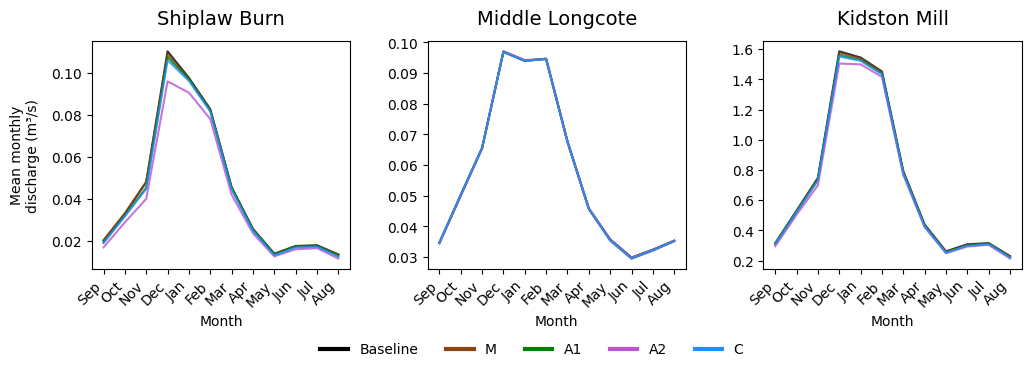

In [ ]:
# Discharge regimes plot

subs = ["SB", "ML", "KM"]
name_map = {"SB":"Shiplaw Burn", "ML":"Middle Longcote", "KM":"Kidston Mill"}
fig, axes = plt.subplots(1, len(subs), figsize=(10, 4), sharex=False, sharey=False)

plt.subplots_adjust(left=0.06, right=0.99, top=0.85, bottom=0.28, wspace=0.3)

for i, sub in enumerate(subs):
    dis = globals()[f"{sub}_discharge_regimes"]
    ax_dis = axes[i]

    dis_col_map = col_map_from_df(dis, colour_dict)

    try:
        dis.plot(ax=ax_dis, color=dis_col_map, alpha=0.8, legend=False)
    except Exception as e:
        print('Discharge plot failed:', e)

    ax_dis.set_title(name_map[sub], fontsize=14, pad=12)
    ax_dis.set_xlabel("Month")
    ax_dis.grid(False)

    ax_dis.set_xticks(range(len(hydro_months)))
    ax_dis.set_xticklabels(hydro_months, rotation=45, ha="right")
    ax_dis.tick_params(labelbottom=True)

    if i == 0:
        ax_dis.set_ylabel("Mean monthly\ndischarge (m³/s)", labelpad=8)

# Combined legend placed below the panel
legend_order = ["baseline", "m", "a1", "a2", "c"]
handles = [Line2D([0], [0], color=colour_dict.get(k, "grey"), lw=3) for k in legend_order]

labels = ["Baseline", "M", "A1", "A2", "C"]

fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.03), ncol=len(legend_order), frameon=False)

plt.savefig("../Results/Figure_42.png", dpi=400, bbox_inches="tight")
plt.show()

In [50]:
# Annual mean discharge change from baseline (%)
scenarios = {
    "baseline": D_baseline,
    "m": D_m,
    "a1": D_a1,
    "a2": D_a2,
    "c": D_c,
}

annual_means = {}

start_date = "2011-03-23"
end_date = "2020-03-05"

for scenario, df in scenarios.items():
    selected = df.loc[start_date:end_date]
    numeric_cols = selected.select_dtypes(include="number").columns
    annual_means[scenario] = (
        selected[numeric_cols]
        .resample("YE")
        .mean()
    )

# Combine into one table
annual_mean_table = pd.concat(
    annual_means,
    names=["scenario", "year"]
).reset_index()

annual_summary = pd.DataFrame({
    "baseline": annual_means["baseline"].mean(),
    "m": annual_means["m"].mean(),
    "a1": annual_means["a1"].mean(),
    "a2": annual_means["a2"].mean(),
    "c": annual_means["c"].mean(),
})

annual_summary["m_change_%"] = (
    (annual_summary["m"] - annual_summary["baseline"])
    / annual_summary["baseline"] * 100
)

annual_summary["a1_change_%"] = (
    (annual_summary["a1"] - annual_summary["baseline"])
    / annual_summary["baseline"] * 100
)

annual_summary["a2_change_%"] = (
    (annual_summary["a2"] - annual_summary["baseline"])
    / annual_summary["baseline"] * 100
)

annual_summary["c_change_%"] = (
    (annual_summary["c"] - annual_summary["baseline"])
    / annual_summary["baseline"] * 100
)

print(annual_summary)

                 baseline         m        a1        a2         c  m_change_%  \
Shiplaw_Burn     0.052334  0.052006  0.051456  0.047464  0.050835   -0.626955   
Middle_Burn      0.033211  0.033224  0.033213  0.025568  0.033225    0.038254   
Middle_Longcote  0.062399  0.062353  0.062380  0.062428  0.062336   -0.073751   
Kidston_Mill     0.860606  0.855083  0.847688  0.826842  0.843784   -0.641682   

                 a1_change_%  a2_change_%  c_change_%  
Shiplaw_Burn       -1.676794    -9.305116   -2.864848  
Middle_Burn         0.006382   -23.012930    0.041290  
Middle_Longcote    -0.031343     0.045558   -0.101509  
Kidston_Mill       -1.500994    -3.923286   -1.954652  


In [40]:
# Relative change
def relative_change(df, colour_dict, relative=True):
    baseline_cols = [c for c in df.columns if c.split("_")[-1] == "baseline"]
    if not baseline_cols:
        raise ValueError(f"No baseline ('baseline') column found in {df.columns.tolist()}")
    baseline_col = baseline_cols[0]

    if relative:
        # % change from baseline, row-wise (per month)
        return df.subtract(df[baseline_col], axis=0).divide(df[baseline_col], axis=0) * 100
    else:
        return df.subtract(df[baseline_col], axis=0)

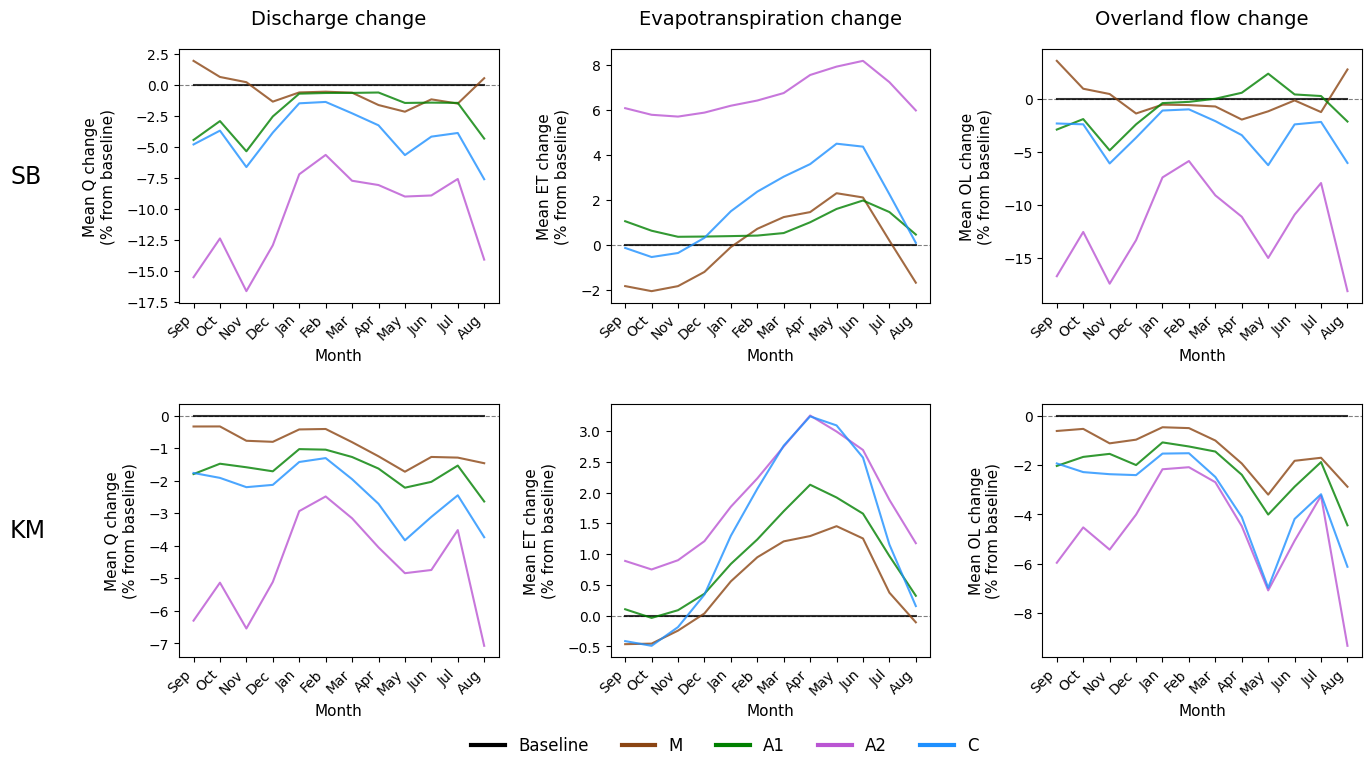

In [52]:
# Relative change plots (Q, ET, and OL) for SB and KM

subs = ["SB", "KM"]
name_map = {"SB":"SB", "KM":"KM"}

fig, axes = plt.subplots(len(subs), 3, figsize=(13, 8), sharex=False, sharey=False)

# set column titles (match plotting order)
axes[0,0].set_title("Discharge change", fontsize=14, pad=18)
axes[0,1].set_title("Evapotranspiration change", fontsize=14, pad=18)
axes[0,2].set_title("Overland flow change", fontsize=14, pad=18)

plt.subplots_adjust(left=0.08, right=0.99, top=0.92, bottom=0.16, hspace=0.4, wspace=0.35)

for i, sub in enumerate(subs):
    dis = globals()[f"{sub}_discharge_regimes"]
    et = globals()[f"{sub}_ET_regimes"]
    ol = globals()[f"{sub}_OL_regimes"]

    dis_change = relative_change(dis, colour_dict)
    et_change = relative_change(et, colour_dict)
    ol_change = relative_change(ol, colour_dict)

    ax_dis = axes[i,0]
    ax_et  = axes[i,1]
    ax_ol  = axes[i,2]

    dis_col_map = col_map_from_df(dis_change, colour_dict)
    et_col_map = col_map_from_df(et_change, colour_dict)
    ol_col_map = col_map_from_df(ol_change, colour_dict)

    try:
        dis_change.plot(ax=ax_dis, color=dis_col_map, alpha=0.8, legend=False)
    except Exception as e:
        print('Discharge plot failed:', e)
    try:
        et_change.plot(ax=ax_et, color=et_col_map, alpha=0.8, legend=False)
    except Exception as e:
        print('ET plot failed:', e)
    try:
        ol_change.plot(ax=ax_ol, color=ol_col_map, alpha=0.8, legend=False)
    except Exception as e:
        print('OL plot failed:', e)

    ax_dis.set_ylabel("Mean Q change\n(% from baseline)", labelpad=8, fontsize=11)
    ax_et.set_ylabel("Mean ET change\n(% from baseline)", labelpad=8, fontsize=11)
    ax_ol.set_ylabel("Mean OL change\n(% from baseline)", labelpad=8, fontsize=11)

    for ax in (ax_dis, ax_et, ax_ol):
        ax.axhline(0, color="grey", linewidth=0.8, linestyle="--", zorder=0)
        ax.grid(False)
        ax.set_xlabel("Month", fontsize=11)
        ax.set_xticks(range(len(hydro_months)))
        ax.set_xticklabels(hydro_months, rotation=45, ha="right")
        ax.tick_params(labelbottom=True)

    pos = ax_dis.get_position()
    y_center = pos.y0 + pos.height / 2
    fig.text(-0.05, y_center, name_map[sub], va='center', ha='left', fontsize=17, clip_on=False)

# Combined legend placed below the panel (outside)
legend_order = ["baseline", "m", "a1", "a2", "c"]
labels = ["Baseline", "M", "A1", "A2", "C"]

handles = [Line2D([0], [0], color=colour_dict[k], lw=3) for k in legend_order]

fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=len(legend_order),fontsize=12, frameon=False)

plt.savefig("../Results/Figure_43.png", dpi=400, bbox_inches="tight")
plt.show()

In [44]:
SB_rel_et = relative_change(SB_ET_regimes, colour_dict, relative=True)
KM_rel_et = relative_change(KM_ET_regimes, colour_dict, relative=True)

SB_rel_ol = relative_change(SB_OL_regimes, colour_dict, relative=True)
KM_rel_ol = relative_change(KM_OL_regimes, colour_dict, relative=True)

SB_rel_q = relative_change(SB_discharge_regimes, colour_dict, relative=True)
KM_rel_q = relative_change(KM_discharge_regimes, colour_dict, relative=True)

print(SB_rel_q)

     baseline         m        a1         a2         c
Sep       0.0  1.920387 -4.462433 -15.532480 -4.823053
Oct       0.0  0.620542 -2.937664 -12.403826 -3.708705
Nov       0.0  0.198421 -5.374209 -16.655351 -6.648056
Dec       0.0 -1.368787 -2.564387 -12.954048 -3.867370
Jan       0.0 -0.626909 -0.727404  -7.229676 -1.505262
Feb       0.0 -0.566347 -0.671893  -5.666827 -1.393732
Mar       0.0 -0.646532 -0.664527  -7.750966 -2.311076
Apr       0.0 -1.643287 -0.633080  -8.096665 -3.279650
May       0.0 -2.181787 -1.474534  -9.023682 -5.681086
Jun       0.0 -1.185026 -1.449217  -8.938391 -4.192561
Jul       0.0 -1.526388 -1.469599  -7.605894 -3.897662
Aug       0.0  0.519820 -4.349156 -14.111536 -7.626928


## Seasonal discharge statistics

In [133]:
# Discharge data

D_scen1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/NewResults/LC_outputs/Eddleston_LC_scen1newMDetailedTS_M11.txt", sep="\\t")
D_scen1["Time"] = pd.to_datetime(D_scen1["Time"])
D_scen1 = D_scen1.set_index("Time")

D_aff1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/NewResults/LC_outputs/Eddleston_LC_aff1newMDetailedTS_M11.txt", sep="\\t")
D_aff1["Time"] = pd.to_datetime(D_aff1["Time"])
D_aff1 = D_aff1.set_index("Time")

D_aff2 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/NewResults/LC_outputs/Eddleston_LC_aff2newMDetailedTS_M11.txt", sep="\\t")
D_aff2["Time"] = pd.to_datetime(D_aff2["Time"])
D_aff2 = D_aff2.set_index("Time")

D_affwet = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/NewResults/LC_outputs/Eddleston_LC_affwetnewMDetailedTS_M11.txt", sep="\\t")
D_affwet["Time"] = pd.to_datetime(D_affwet["Time"])
D_affwet = D_affwet.set_index("Time")

D_wet = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/NewResults/LC_outputs/Eddleston_LC_wetnewMDetailedTS_M11.txt", sep="\\t")
D_wet["Time"] = pd.to_datetime(D_wet["Time"])
D_wet = D_wet.set_index("Time")

/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_38750/301074096.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  D_scen1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/NewResults/LC_outputs/Eddleston_LC_scen1newMDetailedTS_M11.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_38750/301074096.py:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  D_aff1 = pd.read_csv("/Users/teganwilliams/Desktop/MScEM/Thesis/NewResults/LC_outputs/Eddleston_LC_aff1newMDetailedTS_M11.txt", sep="\\t")
/var/folders/6k/k4px0zc93gxbk1b2nnkh3gdr0000gn/T/ipykernel_38750/301074096.p

In [53]:
# Seasonal statistics only for each LC scenario

scenarios = {
    "Baseline": D_baseline,
    "A1": D_a1,
    "A2": D_a2,
    "C": D_c,
    "M": D_m,
}

month_to_season = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}

def compute_summary(df):
    return pd.DataFrame({
        "mean": df.mean(),
        "p05": df.quantile(0.05),
        "p95": df.quantile(0.95),
    })

def compute_seasonal_summary(df):
    temp = df.copy()
    temp["season"] = temp.index.month.map(month_to_season)
    data_cols = [col for col in temp.columns if col != "season"]
    return (
        temp
        .groupby("season")
        .apply(lambda group: compute_summary(group[data_cols]))
        .rename_axis(index=["season", "subcatchment"])
        .reset_index()
    )

seasonal_results = []
for scenario_name, df in scenarios.items():
    seasonal = compute_seasonal_summary(df)
    seasonal["scenario"] = scenario_name
    seasonal_results.append(seasonal)

seasonal_stats_all = pd.concat(seasonal_results, ignore_index=True)
# ensure column order and round numeric values to 3 decimals
seasonal_stats_all = seasonal_stats_all[["scenario", "season", "subcatchment", "mean", "p05", "p95"]]
seasonal_stats_all[["mean", "p05", "p95"]] = seasonal_stats_all[["mean", "p05", "p95"]].round(5)

print("\nSeasonal statistics for all LC scenarios (rounded to 3 decimals)")
print(seasonal_stats_all.head(20))

output_path = Path("../Results/Seasonal_flow_stats_by_scenario.csv")
seasonal_stats_all.to_csv(output_path, index=False)
print(f"\nExported seasonal summary table to: {output_path}")


Seasonal statistics for all LC scenarios (rounded to 3 decimals)
    scenario season     subcatchment     mean      p05      p95
0   Baseline    DJF     Shiplaw_Burn  0.09719  0.01167  0.32127
1   Baseline    DJF      Middle_Burn  0.06046  0.00917  0.19708
2   Baseline    DJF  Middle_Longcote  0.09523  0.03081  0.22165
3   Baseline    DJF     Kidston_Mill  1.52995  0.20788  4.83931
4   Baseline    JJA     Shiplaw_Burn  0.01645  0.00430  0.04532
5   Baseline    JJA      Middle_Burn  0.01093  0.00344  0.03501
6   Baseline    JJA  Middle_Longcote  0.03256  0.00854  0.08061
7   Baseline    JJA     Kidston_Mill  0.28495  0.07342  1.00425
8   Baseline    MAM     Shiplaw_Burn  0.02817  0.00689  0.10426
9   Baseline    MAM      Middle_Burn  0.01781  0.00491  0.06002
10  Baseline    MAM  Middle_Longcote  0.04951  0.01666  0.09840
11  Baseline    MAM     Kidston_Mill  0.49296  0.10058  1.80928
12  Baseline    SON     Shiplaw_Burn  0.03374  0.00366  0.13964
13  Baseline    SON      Middle_Burn  